## Домашнє завдання на тему "Перевірка вибірки на нормальність"

0.Зчитайте дані з `data.csv` та запишіть значення колонки data у форматі np.ndarray в змінну data. Ми будемо далі працювати з цією змінною.

In [1]:
import numpy as np
import pandas as pd

In [61]:
data = pd.read_csv('/Users/s1ndly/Data Analytics/data/data_statistics/data.csv')
data = data['data'].to_numpy()

Запустіть код нижче. Для коректної робити всіх подальших методів дані мають бути у вигляді одновимірного вектора, тобто мати розмір (100,).

In [62]:
data.shape

(100,)

## Перевірка вибірки на нормальність

1.**Візуалізація розподілу**

Подивимось спершу на розподіл наших даних. Для цього побудуємо розподіл даних (графік на вигляд як гістограма, тільки він нормований так, аби сума під кривою була рівна 1), а на нього накладемо лінійний графік щільності (PDF - для побудови використовуємо `scipy.stats.norm.pdf(...)`) теоретичного нормального розподілу з середнім та стандартним відхиленням як у наших даних.

Візуалізацію будуємо за аналогією прикладу, що наводився у лекції, коли ми будували кілька кривих щільності для одних і тих самих даних, тільки значно більш спрощено, бо розподіл для порівняння у нас лише один - нормальний.

Побудуйте графік як наведено в очікуваному результаті та напишіть ваш висновок, чи схоже, що дані розподілені нормально?

Підказка: весь графік будується за 6 рядків коду, три з яких - підписи осей і графіку. Аби побудувати лінійний графік функції щільності та він наклався на гістограму, необхідно задати значення іксів з діапазону значень наших даних. Ці значення вже задані для вас, залишилось дописати 5 рядочків коду :)

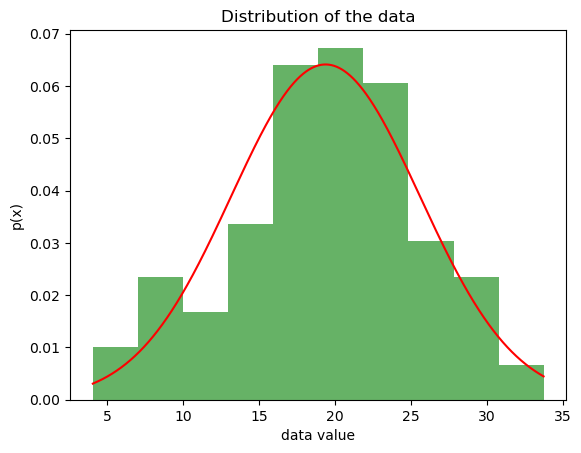

In [38]:

from scipy.stats import norm

x_axis = np.arange(data.min(), data.max(), 0.01)
# ... ваш код далі

"""""
mean_data = np.mean(data)
std_data = np.std(data)

data_pdf = norm.pdf(x_axis, loc=mean_data, scale=std_data)
"""

data_pdf = norm.pdf(x_axis, loc=np.mean(data), scale=np.std(data))

#plt.figure(figsize=(7,5))
plt.hist(data, density=True, alpha=0.6, color='g')
plt.plot(x_axis, data_pdf, '-r')
plt.title('Distribution of the data')
plt.xlabel('data value')
plt.ylabel('p(x)')
plt.show();

The data is relatively normally distributed, although there is a slight deviation in couple of places

In [25]:
from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np

Очікуваний результат:

![](https://drive.google.com/uc?export=view&id=1SB_HOIgwfZXrtglBBlDfMYjg2eGGBSIX)


2.**QQ графік**

Ще одним візуалізаційним методом перевірки розподілу вибірки даних на нормальність є графік квантиль-квантиль, Q-Q графік або QQ графік. У лекції ми розбирали, що це за графік, та як його інтерпретувати.

Побудуйте QQ-Plot для порівняння з нормальним розподілом наших даних та напишіть висновок з графіку, чи можна сказати, що дані розподілені за нормальним законом?

In [51]:
sorted_data = np.sort(data)
data

array([ 4.04330326,  5.39139454,  5.93838085,  7.18282343,  7.75806171,
        7.79920072,  8.79145607,  8.84832568,  9.23938649,  9.57224297,
       11.36336584, 11.47269664, 11.692888  , 12.52827148, 12.87432628,
       13.29244733, 13.40756632, 13.65228669, 14.06732571, 14.54595431,
       14.73135264, 14.93471778, 14.94951581, 15.02518827, 15.5127743 ,
       15.93394654, 16.08049839, 16.17406993, 16.19192417, 16.4230418 ,
       17.22796791, 17.48410111, 17.49945292, 17.57664638, 17.71090111,
       17.71344489, 17.74598346, 17.9670682 , 17.98593597, 18.11895082,
       18.38565824, 18.58289581, 18.69718839, 18.86318441, 19.06139498,
       19.07902883, 19.20602661, 19.45128426, 19.53668801, 19.55317542,
       19.66239904, 19.76257856, 19.88521702, 20.00005857, 20.05415151,
       20.24923636, 20.27753314, 20.28782355, 20.39893405, 20.52626131,
       20.67635903, 21.22524787, 21.29669604, 21.53942271, 21.9560206 ,
       22.10533096, 22.22266722, 22.28283182, 22.2911974 , 22.60

In [57]:
import scipy.stats as stats

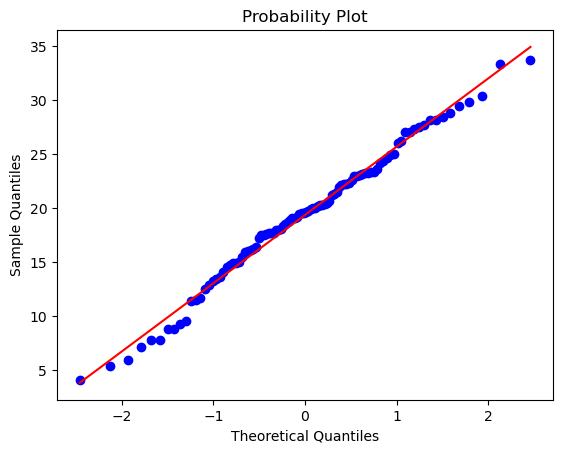

In [63]:
stats.probplot(data, dist="norm", plot=plt)
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.show();

Очікуваний результат:

![](https://drive.google.com/uc?export=view&id=1-eDd16OVgqEjzFUBjJJzSMcwSrzNNm_V)

3.**Тест Шапіро-Вілка**

Тест Шапіро-Вілка визначає для вибірки, наскільки ймовірно, що вона була витягнута з нормального розподілу.
Нульова гіпотеза H0 тесту Шапіро-Вилка полягає в тому, що випадкова величина, вибірка якої відома, розподілена за нормальним законом. Альтернативна гіпотеза H1 полягає в тому, що закон розподілу **не** є нормальним.

**Задача**: протестувати нашу вибірку на нормальність з допомогою теcта Шапіро-Вілка, реалізованого в функцію [scipy.stats.shapiro](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.shapiro.html). Висновок зробіть на основі аналізу p-значення. На рівні значущості = 0.05 чи можемо ми відхилити гіпотезу Н0? Відповідь можна надати текстом, або написати простий if-else блок для виведення висновку спираючись на отримане p-значення. Нагадування:
- p <= alpha: відхиляємо H0.
- p > alpha: не можемо відхилити H0.

Також пропоную вам переглянути оце [відео](https://youtu.be/eh9eYLBecWk), тут розказується про QQ графік, тест Шапіро, та звʼязок між ними.


In [66]:
shapiro_statistic, shapiro_p_value = stats.shapiro(data)
print(f"Shapiro-Wilk Test Statistic: {shapiro_statistic}")
print(f"Shapiro-Wilk Test p-value: {shapiro_p_value}")

if shapiro_p_value > 0.05:
    print("The data follows a normal distribution (fail to reject H0). There is no significant evidence against normality.")
else:
    print("The data does not follow a normal distribution (reject H0). There is significant evidence against normality.")

Shapiro-Wilk Test Statistic: 0.9887855685963715
Shapiro-Wilk Test p-value: 0.5677973106978921
The data follows a normal distribution (fail to reject H0). There is no significant evidence against normality.
